# Simple Deep Learning On Male Data - ASVspoof2019 Dataset:

In [1]:
import sys
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
seed = 5  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\__init__.py:177: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
#To get my GPU device - GTX 4070 :)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


In [3]:
from ASV_utils.data_loading import *


data_path_male = "Data/pmf_both/not_normalize/male/"


embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex  = load_data_male(data_path_male)



## Preprocessing channels

Here, I will perform preprocessing and rearrange the channel order before feeding it into the Deep Neural Network (DNN).

In [4]:
#order by this example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Hellinger-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Intersection-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Jensen-Shannon-[d_(p,p_s)-d(p,p_h)

# get the real channel by the order of the features

import utils.my_functions as my_functions
columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)
embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

In [5]:
# order by metric type and then by channel number and then by gammatone and gammatone_inv, example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
import re


your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract filter type, channel number, and distance metric
    match = re.search(r'filter-(gammatone|gammtone_inv)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        filter_type = match.group(1)  # 'gammatone' or 'gammtone_inv'
        channel = int(match.group(2))
        distance_metric = match.group(3)
        
        # Prioritize 'gammatone' before 'gammtone_inv'
        filter_priority = 0 if filter_type == 'gammatone' else 1

        # Sort by filter type, then by distance metric, and finally by channel
        return (filter_priority, distance_metrics.index(distance_metric), channel)

    else:
        # If the regex doesn't match, push the item to the end
        return (999, 999, 999)

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]

In [6]:
sorted_list

['filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-3-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
 'filter-gammatone-channel-4-distance-Correlation-[d_(p,p_s)

In [7]:
#create the datasets
train_dataset = dataset(data = embedded_groups_1_1 , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id,sex = male_chosen_labels_1_1_sex, data_transform = None , labels_transform = None);

validation_dataset = dataset(data = embedded_groups_1_2 , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = male_chosen_labels_2_1_sex ,data_transform = None , labels_transform = None);


test_dataset = dataset(data = embedded_groups_1_3 , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = male_chosen_labels_3_1_sex ,data_transform = None , labels_transform = None);

In [8]:
# normalize the train, validation and test datasets
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(train_dataset.data)
mean_features = scaler.mean_
std_features = scaler.scale_
train_dataset.data = scaler.transform(train_dataset.data)
validation_dataset.data = scaler.transform(validation_dataset.data)
test_dataset.data = scaler.transform(test_dataset.data)

In [9]:
# balanced the data with SVM SMOTE
import imblearn.over_sampling as over_sampling

sm = over_sampling.SVMSMOTE(sampling_strategy='minority', random_state=seed,k_neighbors=5)
train_dataset.data , train_dataset.is_spoofed  = sm.fit_resample(X = train_dataset.data , y = train_dataset.is_spoofed) # just on the train set

In [10]:
#check if the data now is balanced
print(f"|| train dataset length - {len(train_dataset)} ||");
print(f"|| train dataset - len_is_spoofed ? \nlength - \n{train_dataset.len_is_spoofed()} ||");
print(f"|| validation dataset length - {len(validation_dataset)} ||");
print(f"|| validation dataset - len_is_spoofed ? \nlength - \n{validation_dataset.len_is_spoofed()} ||");
print(f"|| test dataset length - {len(test_dataset)} ||");
print(f"|| test dataset - len_is_spoofed ? \nlength - \n{test_dataset.len_is_spoofed()} ||");

|| train dataset length - 18816 ||
|| train dataset - len_is_spoofed ? 
length - 
0    9408
1    9408
Name: count, dtype: int64 ||
|| validation dataset length - 8260 ||
|| validation dataset - len_is_spoofed ? 
length - 
1    7392
0     868
Name: count, dtype: int64 ||
|| test dataset length - 21939 ||
|| test dataset - len_is_spoofed ? 
length - 
1    19656
0     2283
Name: count, dtype: int64 ||


In [11]:
# define the labels types
train_dataset.set_labels_format('is_spoofed')
validation_dataset.set_labels_format('is_spoofed')
test_dataset.set_labels_format('is_spoofed')

In [12]:
# define the dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True);
validation_dataloader = DataLoader(validation_dataset, batch_size=256, shuffle=True);
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=True);

print(f"|| train dataloader length - {len(train_dataloader)} ||");
print(f"|| validation dataloader length - {len(validation_dataloader)} ||");
print(f"|| test dataloader length - {len(test_dataloader)} ||");

|| train dataloader length - 74 ||
|| validation dataloader length - 33 ||
|| test dataloader length - 86 ||


## Deep Neural Network

Here I define the netwok and training the model.

In [13]:

# define the subchannel model network
import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 

        
    def forward(self, x):
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        return x

In [14]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss

# define the model network
class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.loss = nn.BCEWithLogitsLoss()
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)



# Just for checking the model and see the number of parameters
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 5
final_output_size = 1
model = []
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size)
model = model.to(device)
print(model)
n = DNN.count_parameters(model)
print("Number of parameters: %s" % n)

DNN(
  (SubChannelNetwork): ModuleList(
    (0-15): 16 x SubChannelNetwork(
      (input_layer): Linear(in_features=10, out_features=5, bias=True)
      (sigmoid): Sigmoid()
      (dropout): Dropout(p=0.2, inplace=False)
      (BN_4): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc_between_subnet): Linear(in_features=80, out_features=40, bias=True)
  (BN): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=40, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (droupout): Dropout(p=0.2, inplace=False)
  (loss): BCEWithLogitsLoss()
)
Number of parameters: 4401


In [15]:
import utils.DNN_functions
model = [] # clear the model
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size) # define the model
model = model.to(device) # send the model to the device

# define the hyperparameters
num_epoch = 300
learning_rate = 0.001
weight_decay = 0.000001
model.optimizer = torch.optim.SGD(model.parameters(),
                                lr=learning_rate,
                                weight_decay=weight_decay);
model.scheduler =  optim.lr_scheduler.StepLR(model.optimizer, step_size=num_epoch, gamma=0.1);


checkpoint_path = "Male_best_model_1_neorun_end_sigmoid.pkl"

training_type = '1_neorun_end_sigmoid'

model,train_losses,validation_losses,train_acc_percentage,validation_acc_percentage,f1_score_validation,validation_total_eer,train_total_err  = utils.DNN_functions.train_model_new(training_type,model,train_dataloader,validation_dataloader ,num_epoch,checkpoint_path=checkpoint_path,patience = None)


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\torch\onnx\_internal\_beartype.py:35: UserWarning: unhashable type: 'list'
  warnings.warn(f"{e}")


on 1: 
      Train Balanced Accuracy:  57.07%
on 1: Train EER:  42.93%
on 1: 
      Validation 1 ,Validation Loss 0.73023 , Validation Balanced Accuracy: 81.04%
on 1: Validation EER:  19.01%
on 1: Validation f1 Score: 80.98%
on 1: 
on 1: 
on 2: 
      Train Balanced Accuracy:  75.49%
on 2: Train EER:  24.51%
on 2: 
      Validation 2 ,Validation Loss 0.70326 , Validation Balanced Accuracy: 82.95%
on 2: Validation EER:  17.05%
on 2: Validation f1 Score: 82.94%
on 2: 
on 2: 
on 3: 
      Train Balanced Accuracy:  77.67%
on 3: Train EER:  22.33%
on 3: 
      Validation 3 ,Validation Loss 0.68377 , Validation Balanced Accuracy: 83.63%
on 3: Validation EER:  16.38%
on 3: Validation f1 Score: 83.62%
on 3: 
on 3: 
on 4: 
      Train Balanced Accuracy:  79.28%
on 4: Train EER:  20.73%
on 4: 
      Validation 4 ,Validation Loss 0.67002 , Validation Balanced Accuracy: 83.77%
on 4: Validation EER:  16.33%
on 4: Validation f1 Score: 83.69%
on 4: 
on 4: 
on 5: 
      Train Balanced Accuracy:  79.57

In [16]:
import pickle
#file_path = 'Male_best_model_9_2.pkl'

# Open the file in binary write mode
#with open(file_path, 'wb') as f:
    # Serialize the object and write it to the file
#    pickle.dump(model, f)

c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\utils\DNN_functions.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


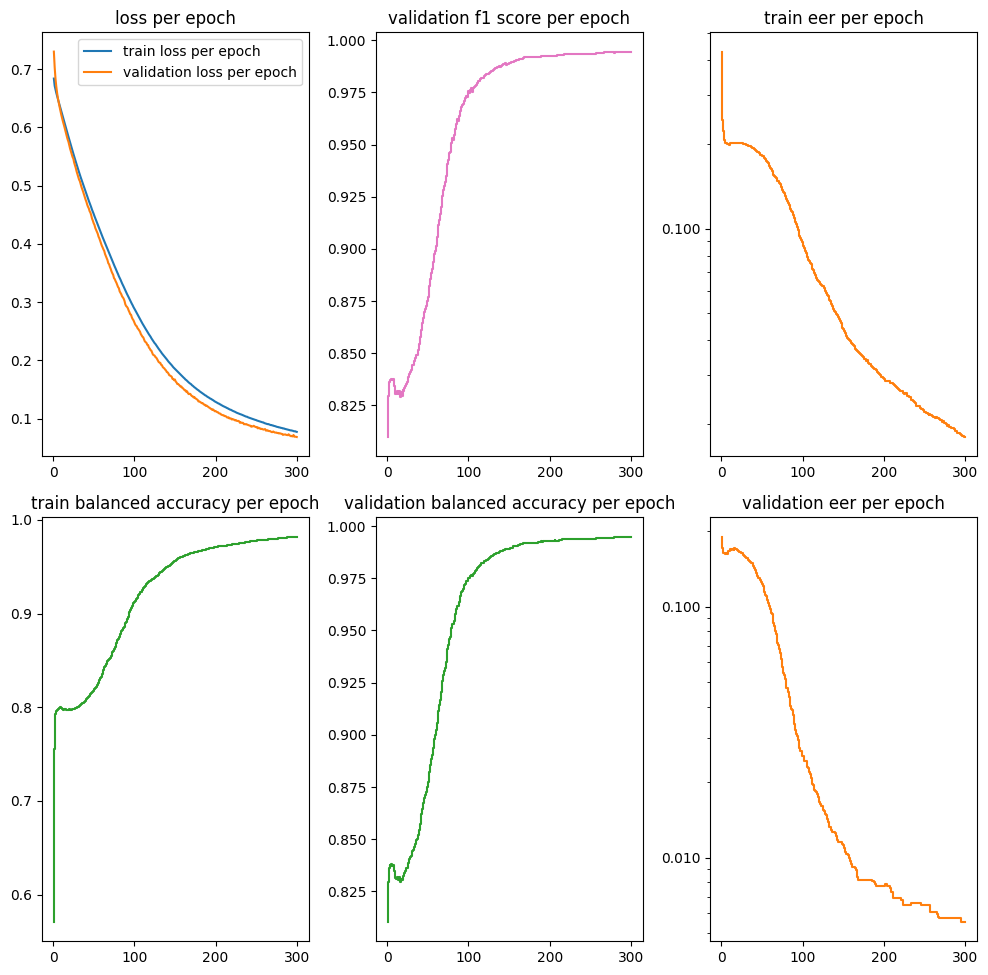

In [17]:
import matplotlib.pyplot as plt
# Plot training & validation accuracy and eer values
DNN_functions.plot_loss_accuracy(num_epoch,train_losses,validation_losses,train_acc_percentage,validation_acc_percentage,f1_score_validation,validation_total_eer,train_total_err)

## Inference on The Test Set

Here, I will conduct inference to assess the outcomes on the test set. 
Additionally, I will evaluate the model's performance on the test set using metrics such as confusion matrix, Equal Error Rate (EER), and balanced accuracy. 
These assessments will involve utilizing thresholds derived from both the validation set and the test set.

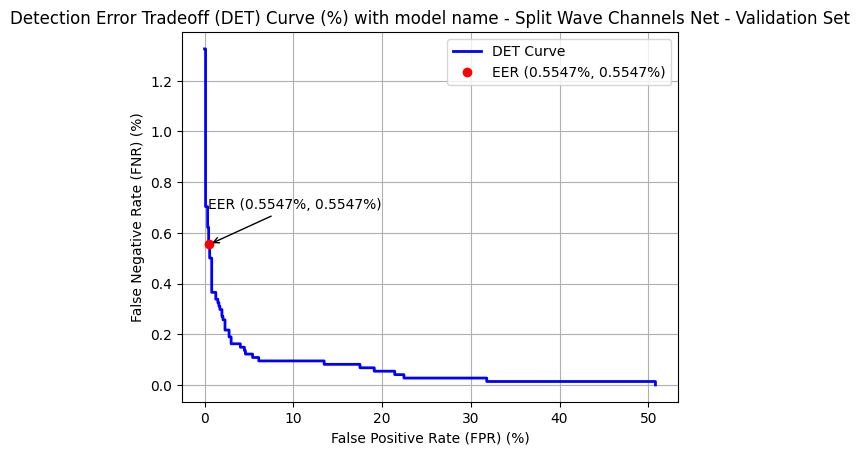

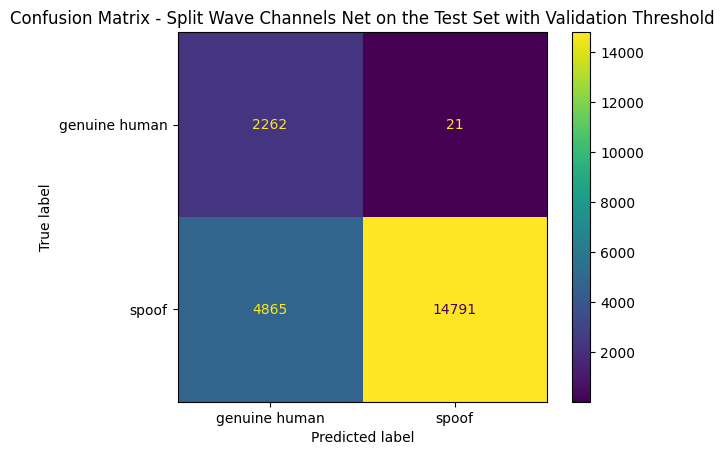

	Test Balanced Accuracy: (0.87165%) 	F1 Score: 0.77729
The validation threshold is:  0.1934174167726178


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import det_curve
import torch.nn.functional as F 

# get the validation probability
with torch.no_grad():
    if training_type == '1_neorun_end_sigmoid':
        validation_prob = torch.sigmoid(model(torch.Tensor(validation_dataset.data)).cpu())
    
valid_total_prob = validation_prob.cpu().numpy().copy() # copy the validation probability

valid_total_labels = validation_dataset.is_spoofed.copy() # copy the validation labels

eer, val_thresh = my_functions.compute_eer(valid_total_labels,valid_total_prob) # compute equal error rate

fpr, fnr, _ = det_curve(valid_total_labels, valid_total_prob) # compute false positive rate and false negative rate

my_functions.DETCurve(fpr = fpr, fnr = fnr, eer_fpr = eer,eer_fnr = eer, model_name = "Split Wave Channels Net - Validation Set",plot_type="step") # plot DET curve

# get the test probability
with torch.no_grad():
    model = model.to(device)
    if training_type == '1_neorun_end_sigmoid':
        test_prob = torch.sigmoid(model(torch.Tensor(test_dataset.data).to(device)).cpu()) # get the test probability

test_total_prob = test_prob.cpu().numpy().copy() # copy the test probability

test_total_labels = test_dataset.is_spoofed.copy() # copy the test labels


prediction = np.array([1 if total_prob_element > val_thresh else 0 for total_prob_element in test_total_prob]) # get the prediction with the validation threshold

valid_thr_prediction_dnn = prediction.copy() # copy the prediction with the validation threshold

# get the confusion matrix with the validation threshold on the test set
cm = sklearn.metrics.confusion_matrix(test_total_labels, valid_thr_prediction_dnn) 
cm = np.round(cm,2)

# print confusion matrix with the validation threshold on the test set
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["genuine human","spoof"])
disp.plot()
plt.title('Confusion Matrix - Split Wave Channels Net on the Test Set with Validation Threshold')
plt.show()

# Calculate the balanced accuracy for the test set with the validation threshold
balanced_acc= sklearn.metrics.balanced_accuracy_score(test_total_labels,valid_thr_prediction_dnn) # balanced accuracy per batch

# Calculate the f1 score for the test set with the validation threshold
f1_score =sklearn.metrics.f1_score(test_total_labels, valid_thr_prediction_dnn, average='micro') # f1 score  

print(f"\tTest Balanced Accuracy: ({balanced_acc:.5f}%) \tF1 Score: {f1_score:.5f}")
print("The validation threshold is: ",val_thresh)

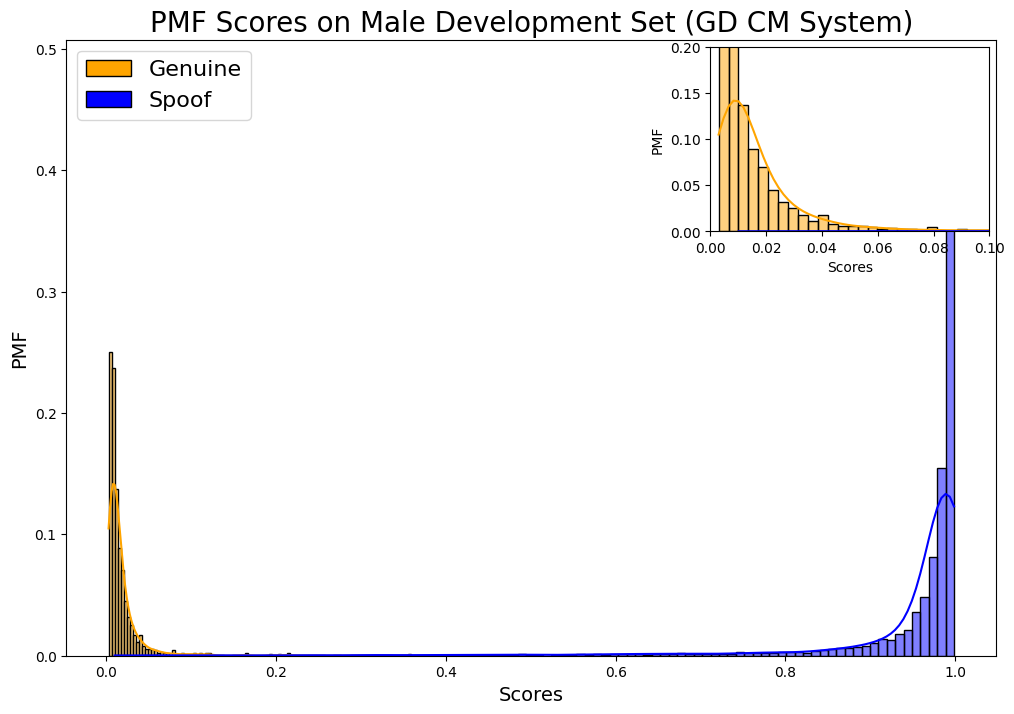

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # For block-style legend

bonafide_scores = valid_total_prob[validation_dataset.is_spoofed == 0].flatten()
spoof_scores = valid_total_prob[validation_dataset.is_spoofed == 1].flatten()

num_bins = 100



# Plot 1: Separate histograms for Genuine and Spoof
fig, ax = plt.subplots(figsize=(12, 8))

sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='orange', linewidth=1, ax=ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='blue', linewidth=1, ax=ax)

ax.legend(['Genuine', 'Spoof'], fontsize=14)
ax.set_xlabel('Scores', fontsize=14)
ax.set_ylabel('PMF', fontsize=14)
ax.set_title("PMF Scores on Male Development Set (GD CM System)", fontsize=20)

# Add inset plot
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

inset_ax = inset_axes(ax, width="30%", height="30%", loc='upper right')  # Position inset
zoom_range = (0, 0.1)  # Adjust zoom range for your data

sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='orange', linewidth=1, ax=inset_ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='blue', linewidth=1, ax=inset_ax)

# Create block-style legend
legend_elements = [
    Patch(facecolor='orange', edgecolor='black', label='Genuine'),
    Patch(facecolor='blue', edgecolor='black', label='Spoof')
]
ax.legend(handles=legend_elements, fontsize=16, loc='upper left')


inset_ax.set_xlim(zoom_range)  # Focus x-axis
inset_ax.set_ylim(0, 0.2)      # Adjust y-axis range if needed
inset_ax.set_xlabel('Scores')        # Optional: remove inset labels for clarity
inset_ax.set_ylabel('PMF')

plt.show()



# # Plot 2: Combined histogram with both datasets
# plt.figure(figsize=(12, 8))
# sns.histplot(
#     [spoof_scores, bonafide_scores],
#     kde=True,
#     stat='probability',
#     bins=num_bins,
#     palette=['blue', 'orange'],
#     linewidth=1,
# )

# plt.legend(['Genuine', 'Spoof'], fontsize=14)
# plt.xlabel('Scores', fontsize=14)
# plt.ylabel('PMF', fontsize=14)
# plt.title("PMF Scores on Male Development Set", fontsize=16)

# plt.show()


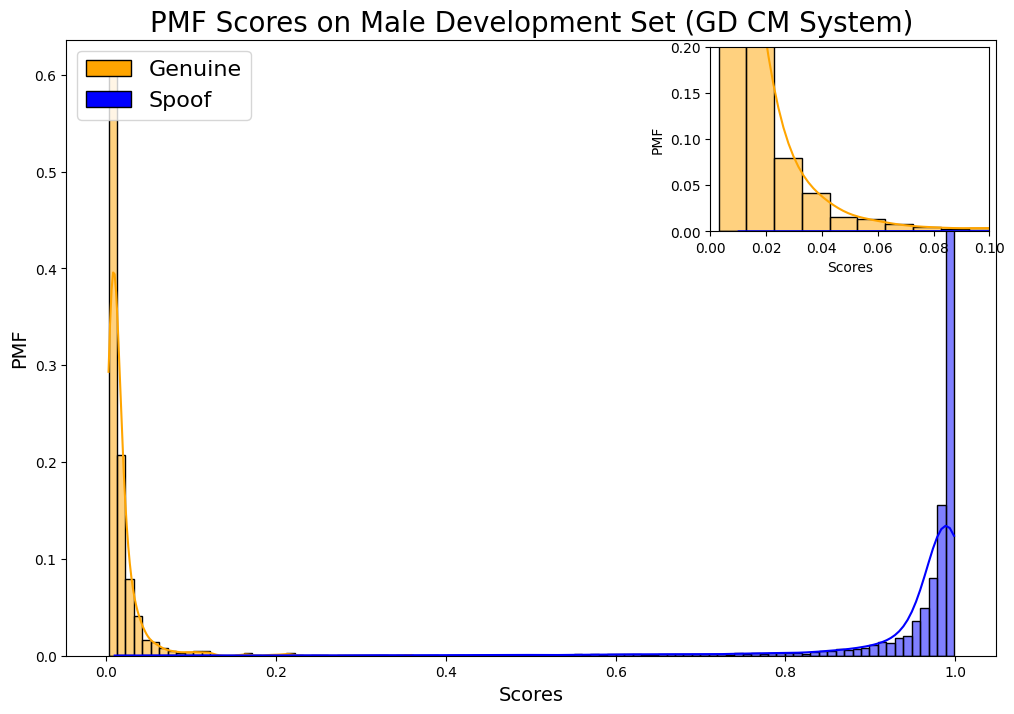

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # For block-style legend
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Compute shared bin edges
num_bins = 100
min_score = min(bonafide_scores.min(), spoof_scores.min())  # Minimum across both distributions
max_score = max(bonafide_scores.max(), spoof_scores.max())  # Maximum across both distributions
bin_edges = np.linspace(min_score, max_score, num_bins + 1)  # Equal-width bins

# Plot 1: Separate histograms for Genuine and Spoof
fig, ax = plt.subplots(figsize=(12, 8))

sns.histplot(bonafide_scores, kde=True, stat='probability', bins=bin_edges, color='orange', linewidth=1, ax=ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=bin_edges, color='blue', linewidth=1, ax=ax)

ax.set_xlabel('Scores', fontsize=14)
ax.set_ylabel('PMF', fontsize=14)
ax.set_title("PMF Scores on Male Development Set (GD CM System)", fontsize=20)

# Create block-style legend
legend_elements = [
    Patch(facecolor='orange', edgecolor='black', label='Genuine'),
    Patch(facecolor='blue', edgecolor='black', label='Spoof')
]
ax.legend(handles=legend_elements, fontsize=16, loc='upper left')

# Add inset plot
inset_ax = inset_axes(ax, width="30%", height="30%", loc='upper right')  # Position inset
zoom_range = (0, 0.1)  # Adjust zoom range for your data

sns.histplot(bonafide_scores, kde=True, stat='probability', bins=bin_edges, color='orange', linewidth=1, ax=inset_ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=bin_edges, color='blue', linewidth=1, ax=inset_ax)

inset_ax.set_xlim(zoom_range)  # Focus x-axis
inset_ax.set_ylim(0, 0.2)      # Adjust y-axis range if needed
inset_ax.set_xlabel('Scores')        
inset_ax.set_ylabel('PMF')

plt.show()


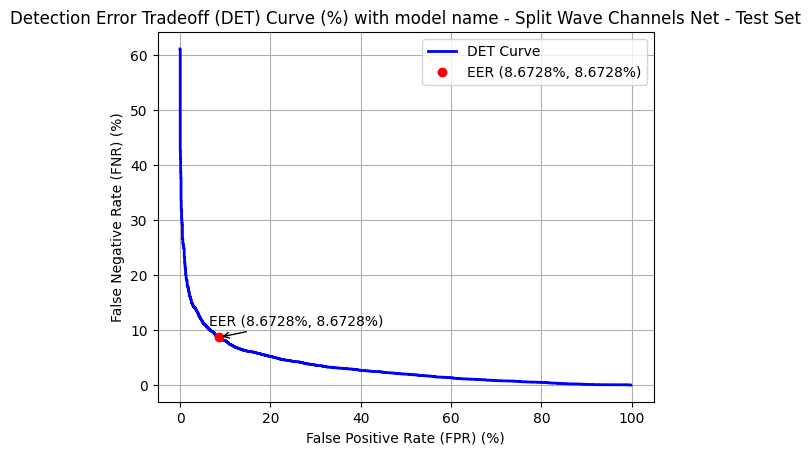

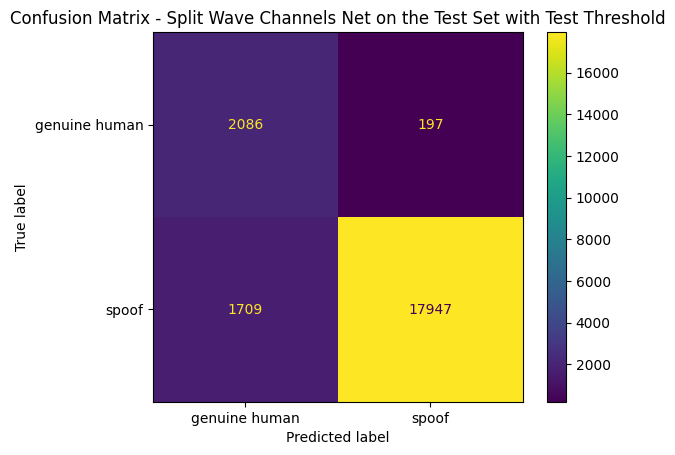

	Test Balanced Accuracy: (0.91338%) 	F1 Score: 0.91312
The test threshold is:  0.04048307612539639


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import det_curve
import torch.nn.functional as F 
# Calculate the inference on the test set with the test threshold

with torch.no_grad():
    model = model.to(device)
    if training_type == '1_neorun_end_sigmoid': 
        test_prob = torch.sigmoid(model(torch.Tensor(test_dataset.data).to(device)).cpu()) # get the test probability
    
test_total_labels = torch.Tensor(test_dataset.is_spoofed.iloc[:]).cpu().numpy().copy() # copy the test labels

test_total_prob_dnn = test_prob.cpu().numpy().copy() # copy the test probability

eer, test_thresh = my_functions.compute_eer(test_total_labels,test_total_prob_dnn) # compute equal error rate

fpr, fnr, _ = det_curve(test_total_labels, test_total_prob_dnn) # compute false positive rate and false negative rate

my_functions.DETCurve(fpr = fpr, fnr = fnr, eer_fpr = eer,eer_fnr = eer, model_name = "Split Wave Channels Net - Test Set",plot_type="step") # plot DET curve
    
prediction = np.array([1 if total_prob_element > test_thresh else 0 for total_prob_element in test_total_prob_dnn]) # prediction with the test threshold

test_thr_prediction_dnn = prediction.copy() # copy the prediction with the test threshold

cm = sklearn.metrics.confusion_matrix(test_total_labels, test_thr_prediction_dnn) # confusion matrix
cm = np.round(cm,2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["genuine human","spoof"])
disp.plot()
plt.title('Confusion Matrix - Split Wave Channels Net on the Test Set with Test Threshold')
plt.show()

#Calculate the balanced accuracy for the test set with the test threshold
balanced_acc= sklearn.metrics.balanced_accuracy_score(test_total_labels,test_thr_prediction_dnn) # balanced accuracy per batch

# Calculate the f1 score for the test set with the test threshold
f1_score =sklearn.metrics.f1_score(test_total_labels, test_thr_prediction_dnn, average='micro') # f1 score  
   
print(f"\tTest Balanced Accuracy: ({balanced_acc:.5f}%) \tF1 Score: {f1_score:.5f}")
print("The test threshold is: ",test_thresh)

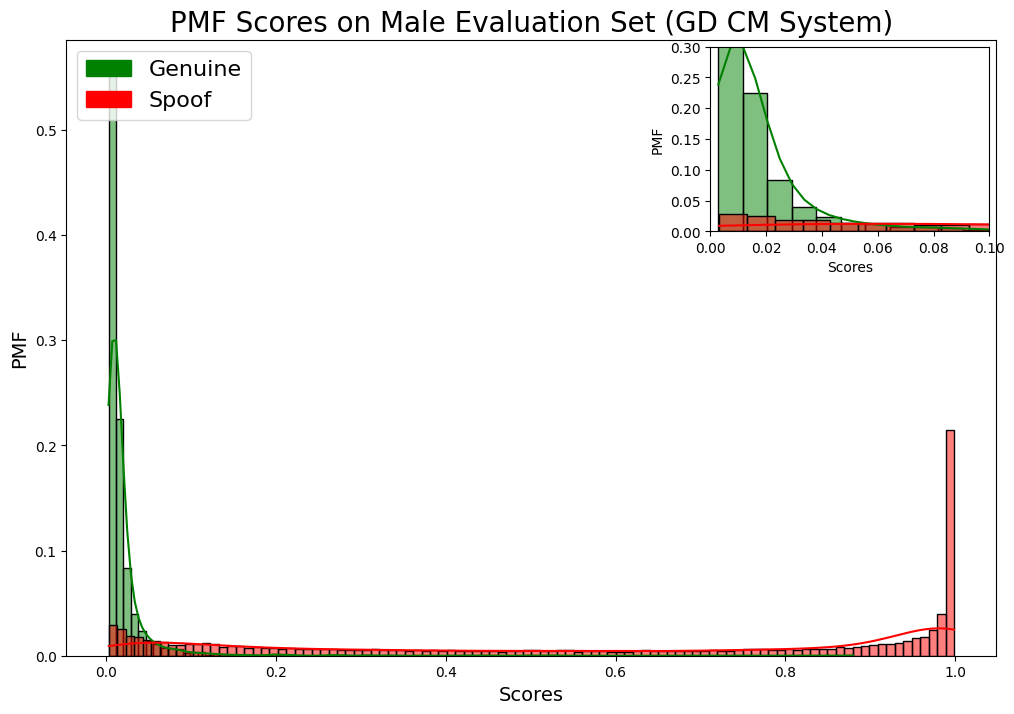

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # For block-style legend

bonafide_scores = test_prob[test_dataset.is_spoofed == 0].flatten()
spoof_scores = test_prob[test_dataset.is_spoofed == 1].flatten()

bonafide_scores = bonafide_scores.cpu().numpy()
spoof_scores = spoof_scores.cpu().numpy()

num_bins = 100
# Colors for the plots
bonafide_color = '#008000'  # Green in hex
spoof_color = '#FF0000'     # Red in hex
# Main figure
fig, ax = plt.subplots(figsize=(12, 8))

# Main plot with histograms
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color=bonafide_color, linewidth=1, ax=ax,legend=True)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color=spoof_color, linewidth=1, ax=ax,legend=True)

# Add labels, title, and legend
ax.set_xlabel('Scores', fontsize=14)
ax.set_ylabel('PMF', fontsize=14)
ax.set_title(f"PMF Scores on Male Evaluation Set (GD CM System)", fontsize=20)
legend_elements = [
    Patch(color=bonafide_color,  label='Genuine'),
    Patch(color=spoof_color,  label='Spoof')
]
ax.legend(handles=legend_elements, fontsize=16, loc='upper left')
#ax.legend(['Genuine', 'Spoof'], fontsize=14, loc='upper left')

# Adding an inset plot
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Define the inset plot
inset_ax = inset_axes(ax, width="30%", height="30%", loc='upper right')  # Adjust size and location

# Zoomed-in region, adjust xlim and ylim based on your data
zoom_range = (0, 0.10)  # Adjust based on your data
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color=bonafide_color, linewidth=1, ax=inset_ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color=spoof_color, linewidth=1, ax=inset_ax)
inset_ax.set_xlim(zoom_range)  # Define zoomed-in x-axis range
inset_ax.set_ylim(0, 0.3)      # Define zoomed-in y-axis range
inset_ax.set_xlabel('Scores')        # Optional: remove inset labels for clarity
inset_ax.set_ylabel('PMF')

plt.show()

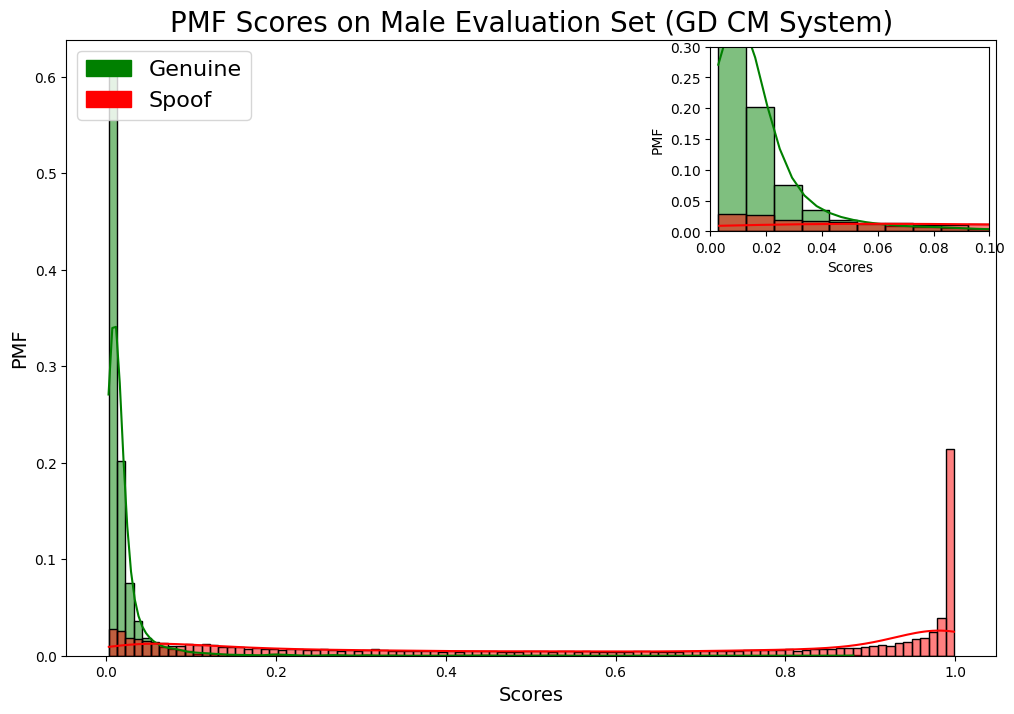

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # For block-style legend
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Convert tensors to numpy
bonafide_scores = test_prob[test_dataset.is_spoofed == 0].flatten().cpu().numpy()
spoof_scores = test_prob[test_dataset.is_spoofed == 1].flatten().cpu().numpy()

# Compute shared bin edges for equal-width bins
num_bins = 100
min_score = min(bonafide_scores.min(), spoof_scores.min())  # Minimum across both distributions
max_score = max(bonafide_scores.max(), spoof_scores.max())  # Maximum across both distributions
bin_edges = np.linspace(min_score, max_score, num_bins + 1)  # Equal-width bins

# Colors for the plots
bonafide_color = '#008000'  # Green in hex
spoof_color = '#FF0000'     # Red in hex

# Main figure
fig, ax = plt.subplots(figsize=(12, 8))

# Main plot with histograms using shared bin edges
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=bin_edges, color=bonafide_color, linewidth=1, ax=ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=bin_edges, color=spoof_color, linewidth=1, ax=ax)

# Add labels, title, and legend
ax.set_xlabel('Scores', fontsize=14)
ax.set_ylabel('PMF', fontsize=14)
ax.set_title("PMF Scores on Male Evaluation Set (GD CM System)", fontsize=20)

# Create block-style legend
legend_elements = [
    Patch(color=bonafide_color, label='Genuine'),
    Patch(color=spoof_color, label='Spoof')
]
ax.legend(handles=legend_elements, fontsize=16, loc='upper left')

# Adding an inset plot
inset_ax = inset_axes(ax, width="30%", height="30%", loc='upper right')  # Adjust size and location

# Zoomed-in region, adjust xlim and ylim based on your data
zoom_range = (0, 0.10)  # Adjust based on your data
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=bin_edges, color=bonafide_color, linewidth=1, ax=inset_ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=bin_edges, color=spoof_color, linewidth=1, ax=inset_ax)

inset_ax.set_xlim(zoom_range)  # Define zoomed-in x-axis range
inset_ax.set_ylim(0, 0.3)      # Define zoomed-in y-axis range
inset_ax.set_xlabel('Scores')        
inset_ax.set_ylabel('PMF')

plt.show()


In [24]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report,accuracy_score
from sklearn.metrics import balanced_accuracy_score


pred_proba_list = [test_total_prob_dnn] # list of the test probability
y_pred = [test_thr_prediction_dnn] # list of the test prediction

test_total_labels = [test_dataset.is_spoofed.iloc[:].astype('uint8')] # list of the test labels

eer_list = []
acc_list = []
balanced_acc_list = []
auc_list = []
f1_list = [] 
# calculate the metrics for the test set with the test threshold
for i in range(0,len(pred_proba_list)): #
     eer , _ = my_functions.compute_eer(test_total_labels[i],pred_proba_list[i])
     eer_list.append(eer)
     acc_list.append(accuracy_score(test_total_labels[i], y_pred[i]))
     balanced_acc_list.append(balanced_accuracy_score(test_total_labels[i], y_pred[i]))
     auc_list.append(roc_auc_score(test_total_labels[i],pred_proba_list[i]))
     f1_list.append(sklearn.metrics.f1_score(test_total_labels[i], y_pred[i]))
  
     
y_pred_with_valid_thr = [valid_thr_prediction_dnn] 

validation_pos_pred_proba_list = [valid_total_prob]    

valid_total_labels = [validation_dataset.is_spoofed.iloc[:].astype('uint8')]


eer_list_on_validaion = []
acc_list_with_valid_thr = []
balanced_acc_list_with_valid_thr = []
f1_list_with_valid_thr = []
# calculate the metrics for the test set with the validation threshold
for i in range(0,len(validation_pos_pred_proba_list)): 
     acc_list_with_valid_thr.append(accuracy_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     balanced_acc_list_with_valid_thr.append(balanced_accuracy_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     f1_list_with_valid_thr.append(sklearn.metrics.f1_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     eer_val , _ = my_functions.compute_eer(valid_total_labels[i],validation_pos_pred_proba_list[i])
     eer_list_on_validaion.append(eer_val)

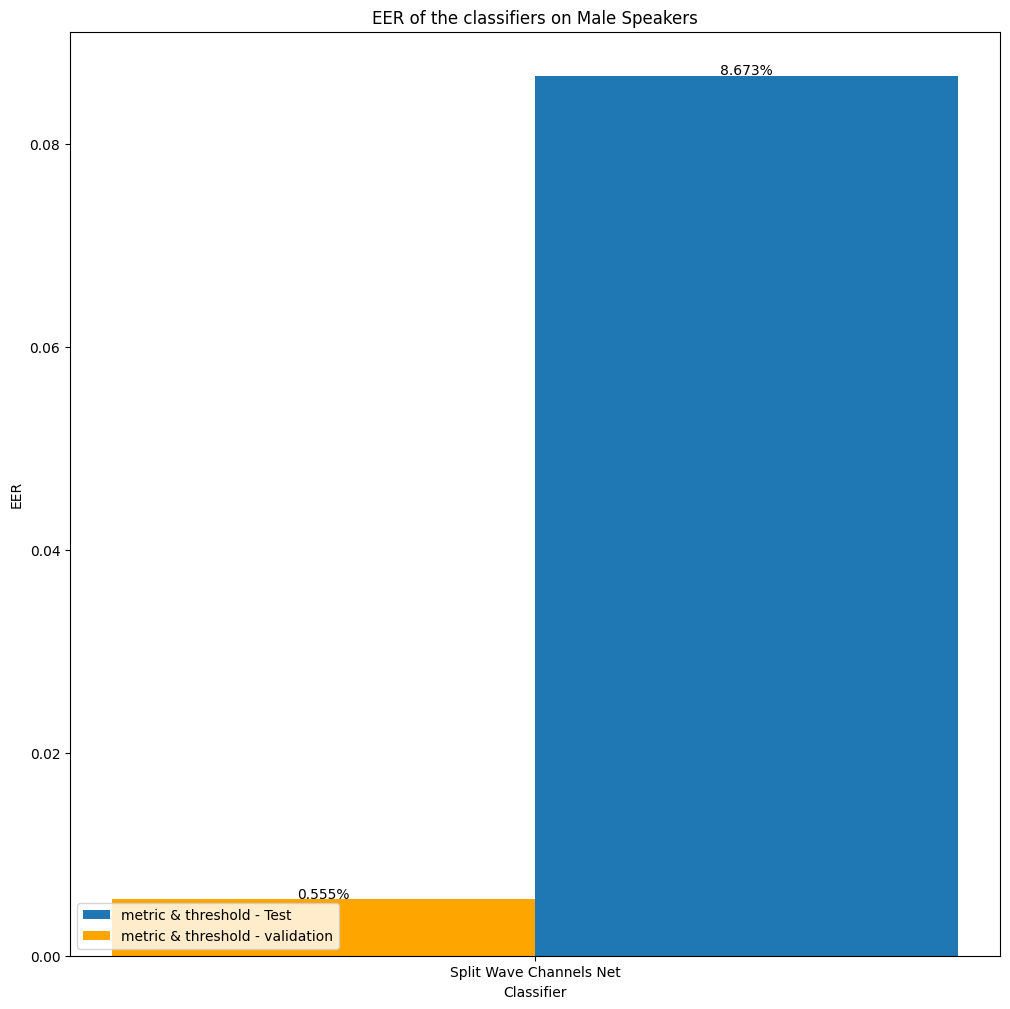

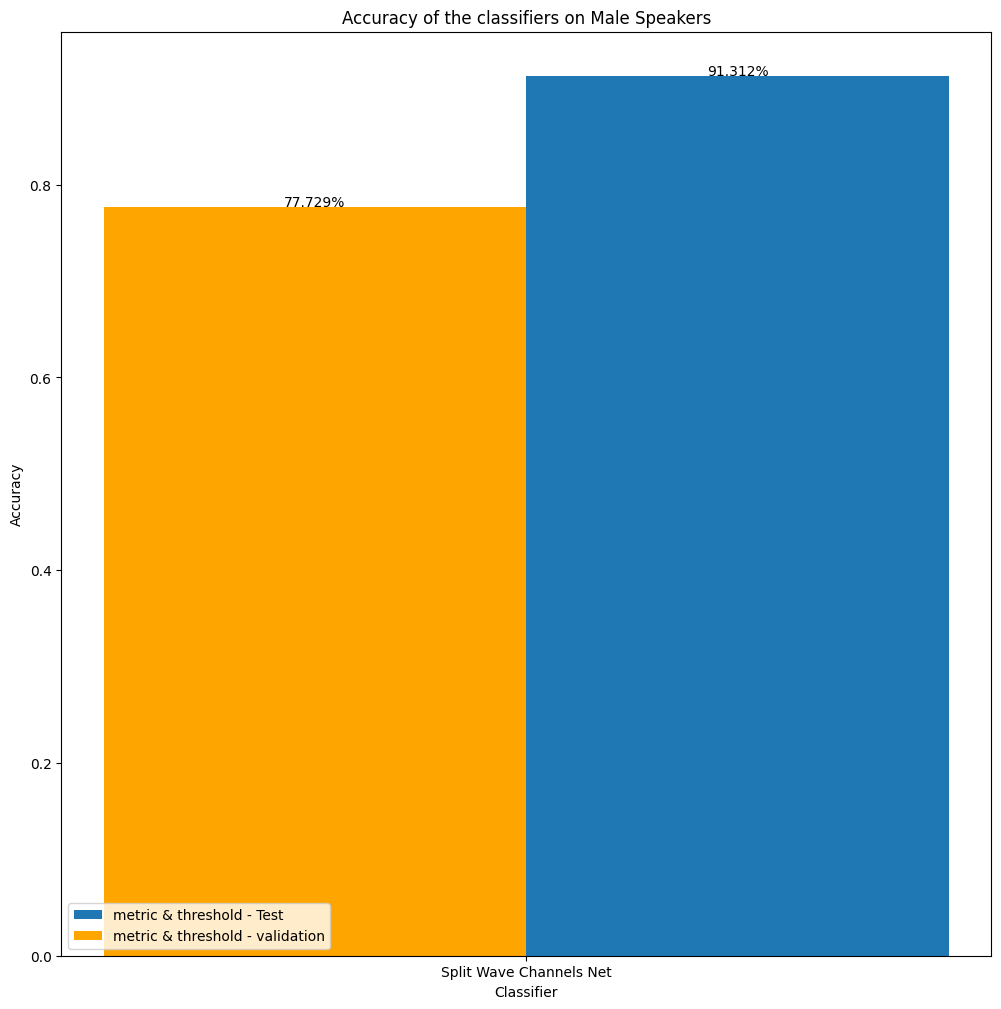

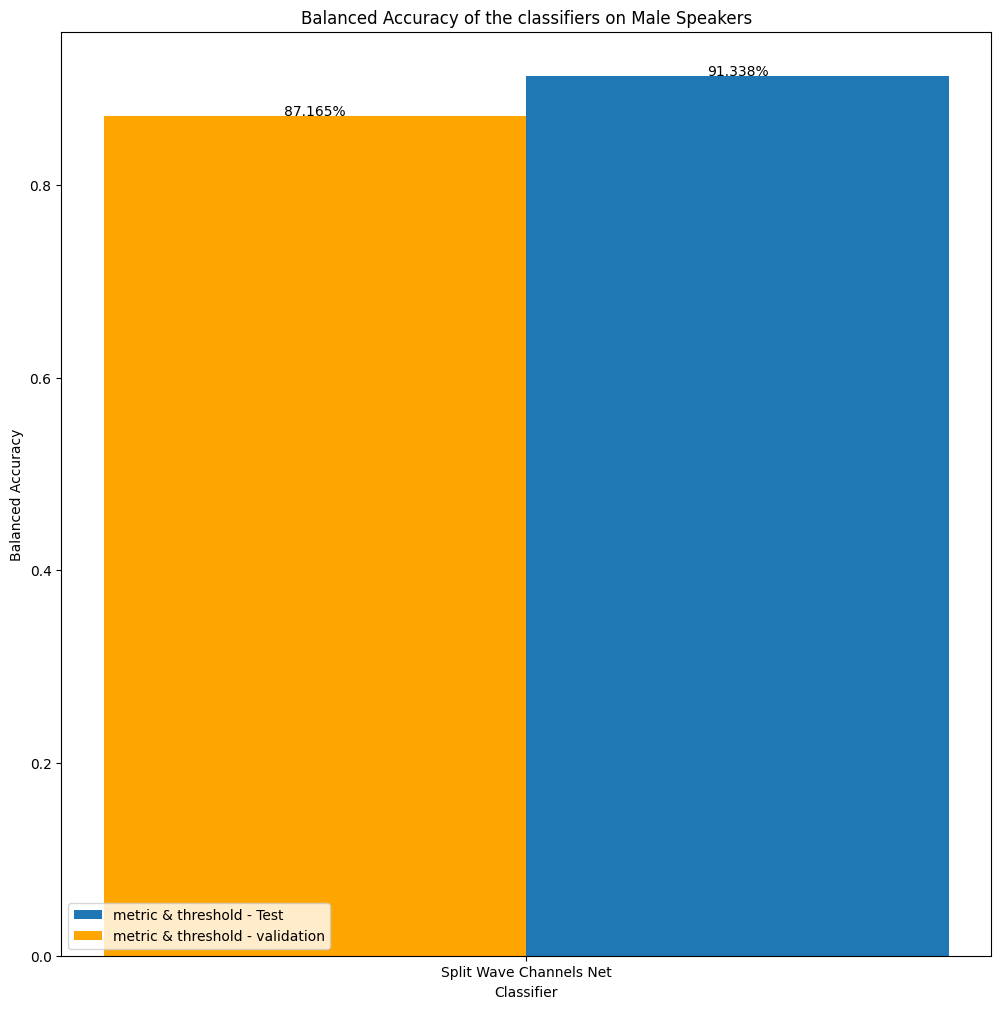

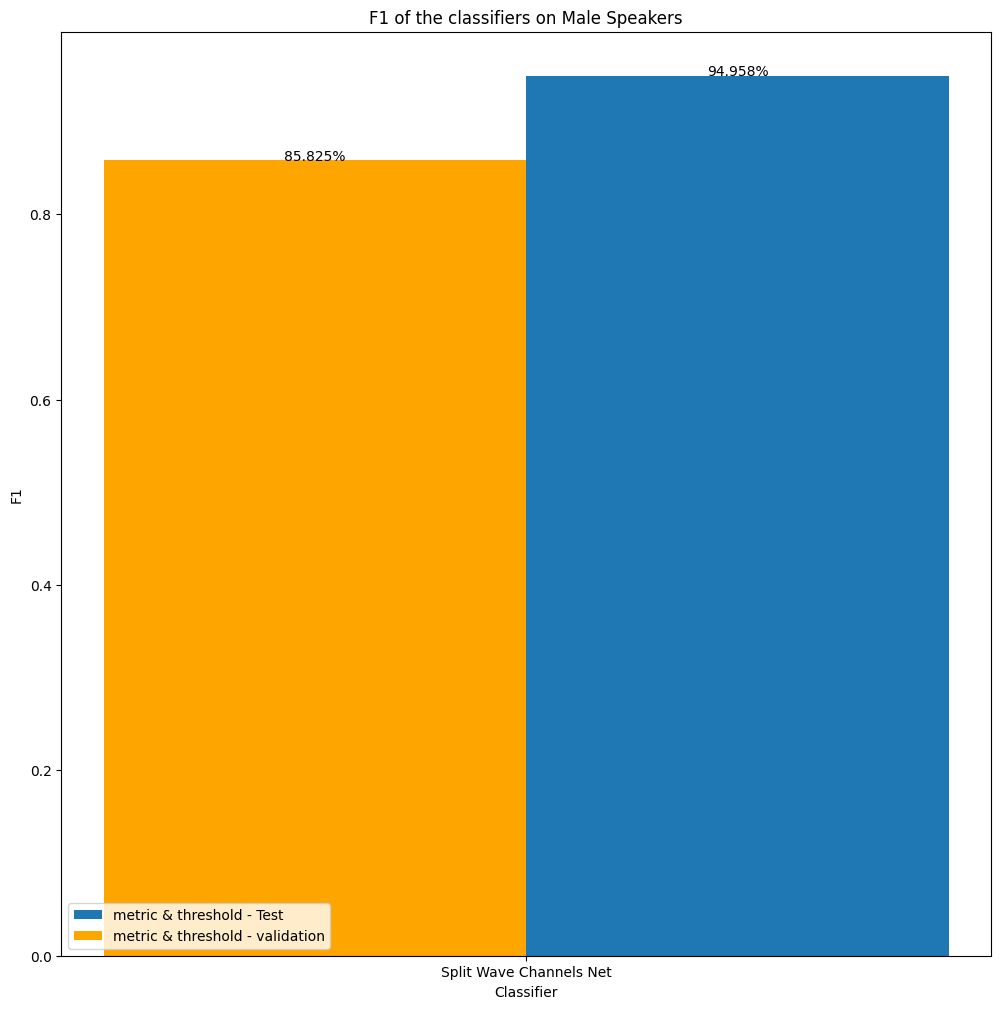

<Figure size 1200x1200 with 0 Axes>

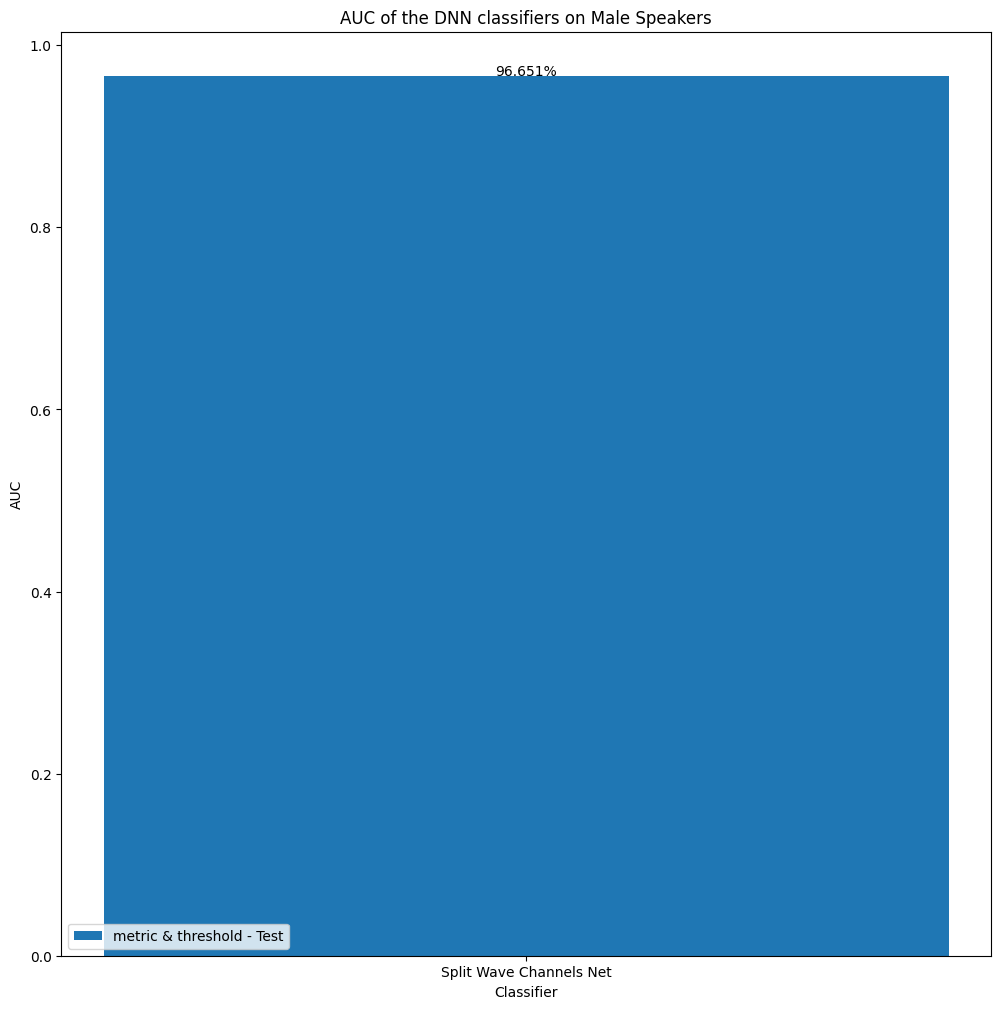

In [25]:
# define the names of the classifiers
names = ['Split Wave Channels Net']
metric_names = ['EER','Accuracy','Balanced Accuracy','F1','AUC']

#plot hisgogram of the results: EER, Accuracy, Balanced Accuracy, AUC
metrics_list = [eer_list,acc_list,balanced_acc_list,f1_list,auc_list] # list of the test metrics
validaion_metrics_list = [eer_list_on_validaion,acc_list_with_valid_thr,balanced_acc_list_with_valid_thr,f1_list_with_valid_thr] # list of the validation metrics

# define the diff for the bar names
diff_for_bar = 0.0001
X_axis = np.arange(len(names))

#Plot the results   
for i in range(0,len(validaion_metrics_list)):
    plt.figure(figsize=(12,12))
    plt.bar(X_axis+0.2, metrics_list[i],width=0.4,label = 'metric & threshold - Test')
    plt.bar(X_axis-0.2, validaion_metrics_list[i],width=0.4,label = 'metric & threshold - validation',color='orange')
    plt.ylabel(metric_names[i])
    plt.xlabel('Classifier')
    plt.title(f"{metric_names[i]} of the classifiers on Male Speakers")
    plt.legend(loc = 'lower left')
    plt.xticks(X_axis, names)
    for j, v in enumerate(metrics_list[i]):
        plt.text(j+0.2, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')
    for j, v in enumerate(validaion_metrics_list[i]):
        plt.text(j-0.2, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')
    plt.show()
    
plt.figure(figsize=(12,12))

i = len(validaion_metrics_list)   

#plot hisgogram of the results: AUC
plt.figure(figsize=(12,12))
plt.bar(X_axis, metrics_list[i],width=0.4,label = 'metric & threshold - Test')
plt.ylabel(metric_names[i])
plt.xlabel('Classifier')
plt.title(f"{metric_names[i]} of the DNN classifiers on Male Speakers")
plt.legend(loc = 'lower left')
plt.xticks(X_axis, names)
for j, v in enumerate(metrics_list[i]):
        plt.text(j, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')   
plt.show()


In [26]:
'''
import pickle

filename = 'male_model_8.83.pkl'
pickle.dump(model, open(filename, 'wb'))
torch.save(model.state_dict(), 'male_model_8.83.pth')
'''

"\nimport pickle\n\nfilename = 'male_model_8.83.pkl'\npickle.dump(model, open(filename, 'wb'))\ntorch.save(model.state_dict(), 'male_model_8.83.pth')\n"